# Sound Analysis with FFT

This notebook performs Fast Fourier Transform (FFT) analysis on audio files to examine their frequency content.

## Import Required Libraries

Import the necessary libraries for signal processing (numpy, scipy) and audio file handling.

In [39]:
from numpy import arange, nonzero
from scipy.fftpack import fft
import scipy.io.wavfile as wav 

## Load Audio File

Read the WAV audio file and extract the sampling frequency and audio signal. Create a time array corresponding to each sample.

Here are some options to use for sounds:

In [40]:
ls ../Sounds/*

../Sounds/90s-Office-Phone.wav          ../Sounds/NorthernCardinal.wav
../Sounds/Applause.wav                  ../Sounds/NorthernCardinal_noise.wav
../Sounds/Boom.wav                      ../Sounds/Volvo850.m4a
../Sounds/Chirping-Birds.wav            ../Sounds/Whip-poor-will.wav
../Sounds/Digital-Seashore.wav          ../Sounds/Yamaha-CS2x-Flute-C5.wav
../Sounds/E-Mu-Proteus-2-Flute-C5.wav   ../Sounds/Yamaha-SY-35-Clarinet-C5.wav


In [ ]:
file_name='../Sounds/Whip-poor-will.wav' # Path to your sound file
Fs, f =wav.read(file_name)
# f = fstereo[:,0] # Take one channel if stereo
nt = len(f)
t= arange(nt)/Fs

dt = 1/Fs
T = nt*dt
t = arange(0,T,dt)

In [42]:
Fs

22050

In [43]:
f.shape

(105399,)

## Plot the Sound Wave

Visualize the audio signal as a function of time to see the waveform of the sound.

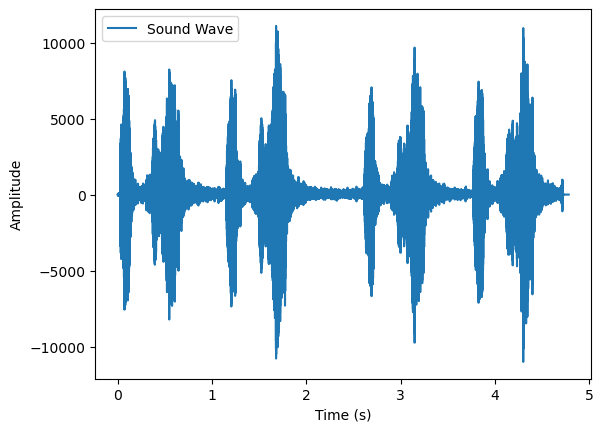

In [44]:
from matplotlib.pyplot import \
    plot,xlabel,ylabel,legend,show, \
    figure, subplot, title, tight_layout

plot(t,f)
xlabel('Time (s)')
ylabel('Amplitude')
legend(['Sound Wave'])
show()

Notice how the time series varies a lot with the bird call. We can sub sample a short portion of the time series for t1 < t < t2 like this:

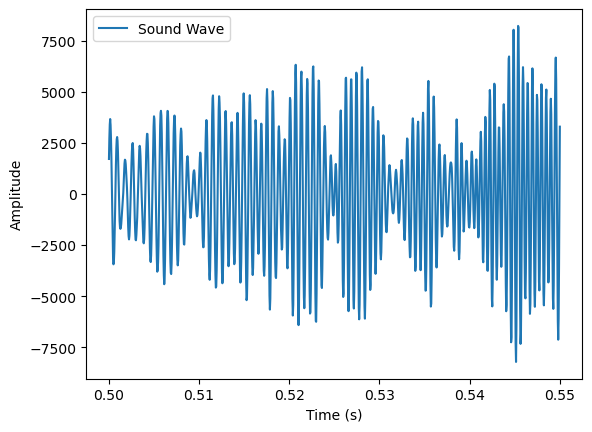

In [45]:
t1 = 0.5
t2 = 0.55

# create a mask
mask = (t1<t) & (t<t2)

# plot only masked data
plot(t[mask],f[mask])
xlabel('Time (s)')
ylabel('Amplitude')
legend(['Sound Wave'])
show()

Now add code to take the FFT and plot the power spectrum for the entire time series. Use code from previous exersizes.

In [46]:
# frequency dimension
T=t[-1]
freqf =  1/T # Hz   fundamental frequency (lowest frequency)
nfmax = int(nt/2) # number of frequencies resolved by FFT

freqmax = freqf*nfmax # Max frequency (Nyquist)

freq = arange(0, freqmax, freqf) # frequency array using arange(start,stop,step)
# Note:
#     include freq=0 (constant term), so freq[0]=0
#     end one term before the  Nyquist (max) frequency, so freq[-1]=freqmax-freqf

print('Fundamental period, Fundamental Frequency and Nyquist Frequency',T,'s', freqf,'Hz', freqmax,'Hz')

Fundamental period, Fundamental Frequency and Nyquist Frequency 4.779954648526077 s 0.20920700582553747 Hz 11025.0 Hz


In [47]:
# take FFT of this function
F = fft(f)


# get the coeffs
a = 2*real(F[:nfmax])/nt # form the a coefficients
a[0] = a[0]/2

b = -2*imag(F[:nfmax])/nt # form the b coefficients

p = sqrt(a**2 + b**2) # form power spectrum


Now use a mask to sub sample short portions of the time series to see how it changes.

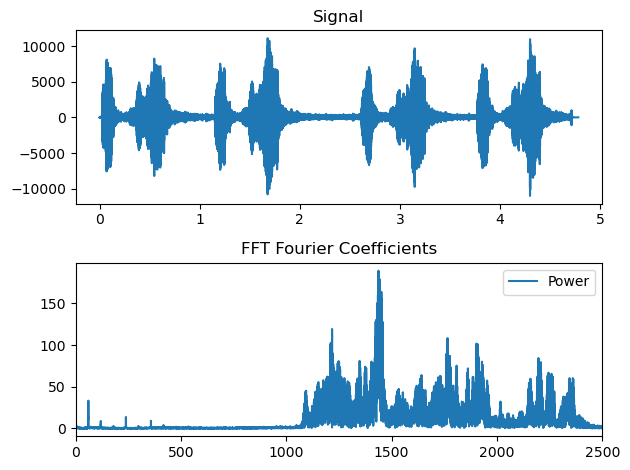

In [49]:
## make some plots

figure(1)

subplot(2,1,1)
plot(t,f)
title('Signal')

subplot(2,1,2)
# plot(freq, a, 'o', label='Cosine')
# plot(freq, b, '*', label='Sine')
plot(freq,p,'-', label='Power')
legend()

title('FFT Fourier Coefficients')
xmax = 2500
xlim(0, xmax)

tight_layout() # prevent squished plot (matplotlib kludge)
